In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
from lmfit.models import GaussianModel
import matplotlib as m

In [2]:
import sklearn
from sklearn.decomposition import PCA

In [3]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [4]:
header = "C:/Users/qipe/Documents/K_Sunada/result/CDK184/"
vac = "/2025-08-13/2025-08-13T092557_150872b0-i0_JPA_vac_squeeze"
dd = datadict_from_hdf5(header + vac +"/data")

[-9.38676368e-04  7.49209250e-04 -2.62635303e-03 ...  8.58183409e-05
 -1.26164643e-03 -1.17561820e-03]
[-0.0026351   0.00309177  0.0015457  ...  0.00056089 -0.00073905
  0.00119281]
[ 3.22013679e-04  1.07767028e-03 -1.88341515e-03 ...  8.03504568e-04
 -6.88816490e-06  2.15230264e-03]
[-7.24178050e-04  2.48688059e-03 -1.52517079e-03 ... -1.62701193e-03
 -3.44027760e-05  1.53375967e-03]
[ 0.00098121  0.00340844  0.00117978 ... -0.00043671 -0.00081419
 -0.00064675]
[-0.00108914 -0.00140999  0.00129957 ...  0.00033246  0.00123619
 -0.001277  ]
[ 0.00039048  0.00122244 -0.00037959 ...  0.00213859  0.0004683
 -0.00047142]
[-0.00046241 -0.00063182  0.00072688 ...  0.00119126 -0.00062128
  0.000375  ]
[-0.00176401 -0.00192521 -0.00186808 ...  0.00232347  0.00106726
 -0.00025339]
[ 0.00026355  0.00389642 -0.00238944 ...  0.0018333   0.00094377
 -0.00091098]
[-0.00060014 -0.00029082  0.00130168 ...  0.00057787  0.00125324
  0.00064502]
[-7.13199329e-04  3.73537746e-04 -7.61889501e-05 ...  9.4692

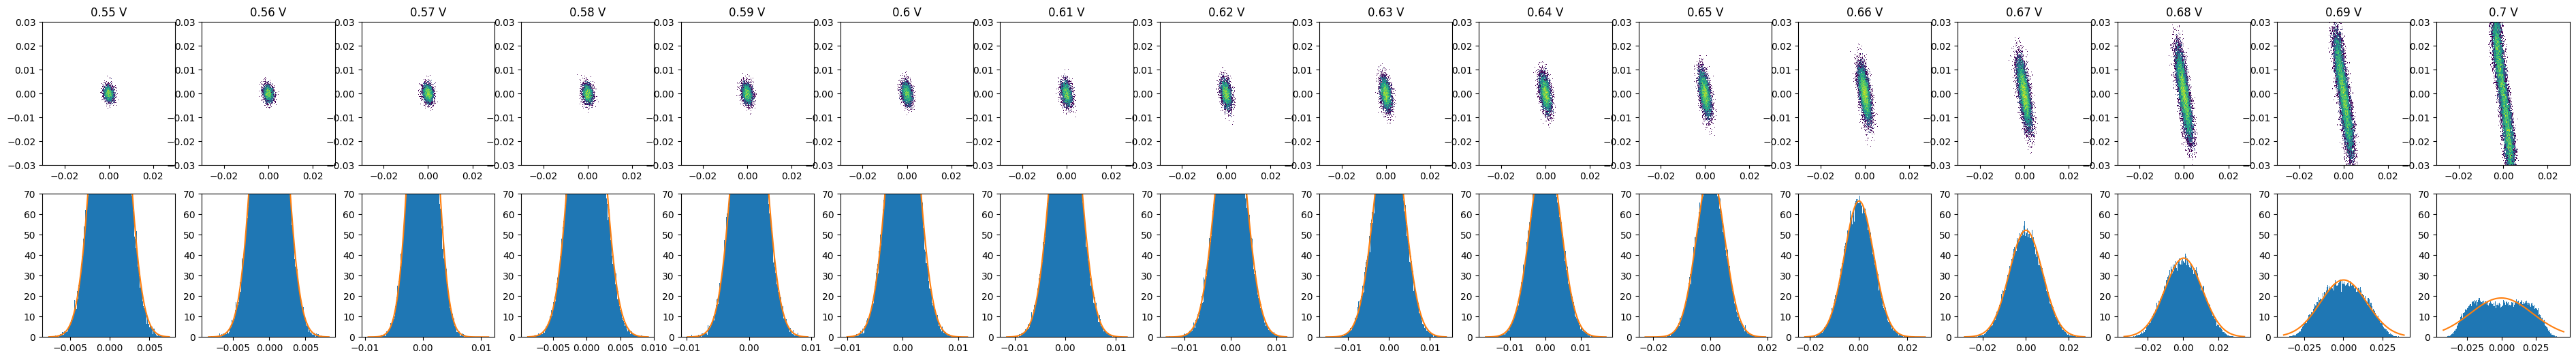

In [5]:
pump_amplitude = dd["pump_amplitude"]["values"]
s11 = dd["s11"]["values"]
fig = plt.figure(figsize=(3 * len(pump_amplitude), 6))
for i in range(len(pump_amplitude)-5):
    i = i+5
    s_11 = s11[i]
    s11_pca = PCA_transform(s_11.real, s_11.imag)[0]
    
    ax = fig.add_subplot(2, len(pump_amplitude), i + 1)
    print(s_11.real)
    ax.hist2d(s_11.real, s_11.imag, bins=200, cmin=1, norm=m.colors.LogNorm())
    ax.set_title(f"{np.round(pump_amplitude[i], decimals=3)} V")
    ax.set_xlim(-0.03, 0.03)
    ax.set_ylim(-0.03, 0.03)

    hist, bins = np.histogram(s11_pca, bins=200, density=True)
    model = GaussianModel()
    params = model.guess(hist, x = bins[1:])
    result = model.fit(hist, params, x = bins[1:])
    ax2 = fig.add_subplot(2, len(pump_amplitude), i + 1 + len(pump_amplitude))
    ax2.hist(s11_pca, bins=200, density=True)
    ax2.set_ylim(0, 70)
    ax2.plot(bins[1:], result.best_fit, label="gaussian fit")
# plt.legend()
plt.show()

phase optimization

In [6]:
data = "/2025-08-13/2025-08-13T093741_b89a6e2e-i1_JPA_phase_optimization_for_ge"  #10dB
dd = datadict_from_hdf5(header + data +"/data")
dd

distance: (51,)
  ⌙ phase (rad): (51,)

(np.float64(0.03218795829088252), np.float64(1.5200000000000002))

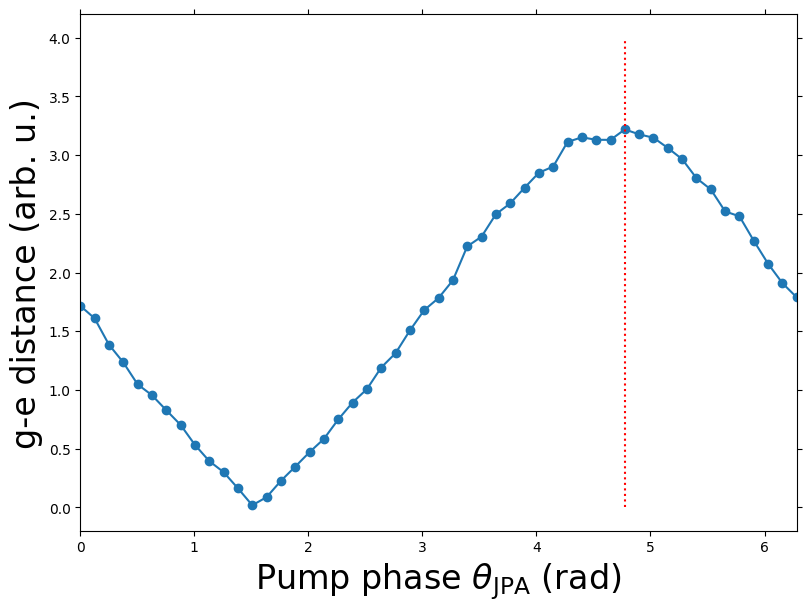

In [7]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

x = dd["phase"]["values"]
y = dd["distance"]["values"]
xy = x[4], np.abs(y)[4]
y_pca = PCA_transform(y.real, y.imag)[0]
plt.title("")
# plt.legend(title_fontsize=18, fontsize=18)
plt.ylabel("g-e distance (arb. u.)", size="large")
plt.xlabel(r"Pump phase $\theta_{\mathrm{JPA}}$ (rad)", size="large")
plt.xlim(0, 2*np.pi)
# plt.ylim(0, 10)
plt.plot(x*np.pi, np.abs(y)*1e2, 'o-')
plt.vlines(1.52*np.pi, 0, 4, color='r', linestyles='dotted')

np.max(np.abs(y)), np.abs(x[38])
# plt.savefig('ge_distance.png', bbox_inches='tight')

readout fidelity

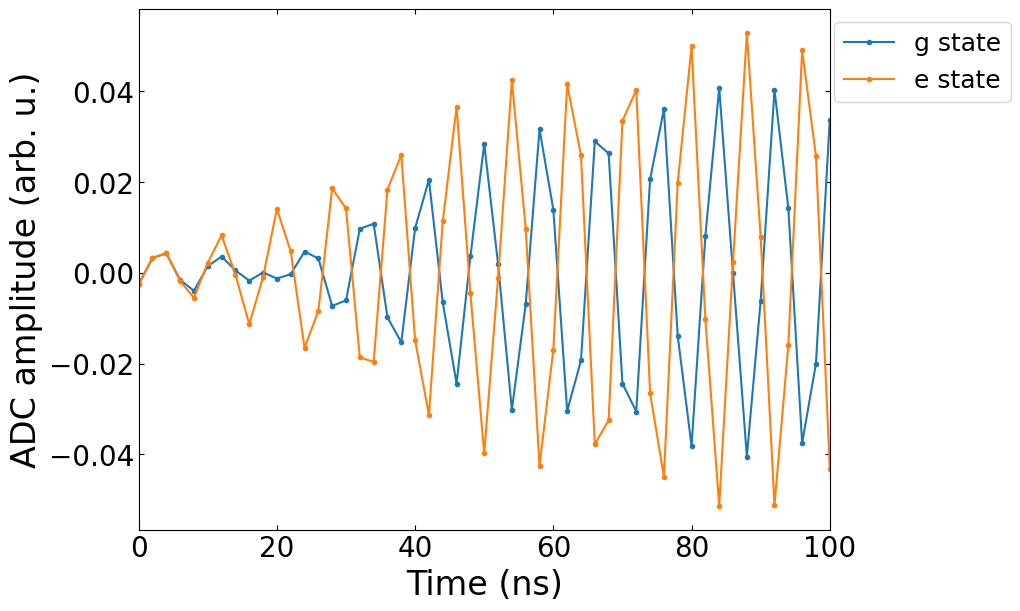

In [8]:
data ="/2025-08-13/2025-08-13T094252_72003c2e-i2_readout_fidelity_threshold"
dd =datadict_from_hdf5(header + data +"/data")
time = dd["time"]["values"][0]
pulse_g = dd["pulse_g"]["values"][0]
pulse_e = dd["pulse_e"]["values"][0]

fig, ax = plt.subplots(figsize=(10,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.title("")
plt.plot(time, pulse_g, '.-', label = "g state")
plt.xlim(0, 100)
plt.plot(time, pulse_e,'.-', label = "e state")
plt.legend(title_fontsize=18, fontsize=18, loc='upper right', bbox_to_anchor=(1.28, 1))
plt.xlabel("Time (ns)", size="large")
plt.ylabel("ADC amplitude (arb. u.)", size="large")
# plt.savefig('JPA_phase_opt.png', bbox_inches='tight')

plt.show()

[0.01494858 0.01513764 0.01135031 ... 0.01796287 0.01248098 0.01178879]


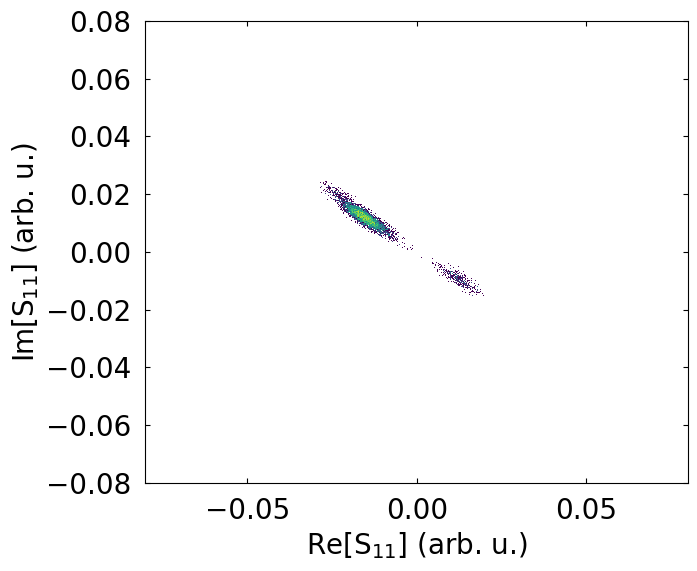

In [9]:
# data ="/2024-06-27/2024-06-27T185724_a73411de-82_readout_fidelity_threshold" #0.7
dd =datadict_from_hdf5(header + data +"/data")
time = dd["time"]["values"][0]
S11_g = dd["signal_g"]["values"][0]
S11_e = dd["signal_e"]["values"][0]
print(S11_g.real)

# s11_g_pca = PCA_transform(S11_g.real, S11_g.imag)[0]
# s11_e_pca = PCA_transform(S11_e.real, S11_e.imag)[0]

fig, ax = plt.subplots(1, 1, figsize=(7,6))
plt.rcParams["font.size"] = 20
plt.tick_params(pad = 10, top='on',bottom='on',left='on',right='on',)
plt.subplots_adjust(wspace=0.3)
ax.hist2d(S11_e.real, S11_e.imag, bins=200, cmin=1, norm=m.colors.LogNorm())
# ax[0].set_title("g")
ax.set_xlim(-0.08, 0.08)
ax.set_ylim(-0.08, 0.08)
ax.set_xlabel('Re[S$_{11}$] (arb. u.)')
ax.set_ylabel('Im[S$_{11}$] (arb. u.)')

# plt.savefig('signal_e.png', bbox_inches='tight')
plt.show()


thermal population

In [21]:
plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.

[ 1.24949843e-03 -4.62694309e-04  7.27870955e-04 -1.80607438e-03
 -1.13978373e-02  5.69505305e-03  3.46512555e-02 -6.93064896e-03
 -7.10435938e-02 -7.52724837e-03  1.13503404e-01  3.69605789e-02
 -1.56937215e-01 -8.57744329e-02  1.91614852e-01  1.50020605e-01
 -2.09806799e-01 -2.25387004e-01  2.08415823e-01  3.05593202e-01
 -1.82911800e-01 -3.83682700e-01  1.32087696e-01  4.51383300e-01
 -6.04289324e-02 -5.04748391e-01 -2.34719253e-02  5.37453778e-01
  1.23731179e-01 -5.49544685e-01 -2.28357195e-01  5.32777046e-01
  3.34635939e-01 -4.93878997e-01 -4.35355039e-01  4.28542607e-01
  5.24419511e-01 -3.49025567e-01 -5.99271178e-01  2.50503610e-01
  6.51744562e-01 -1.36468180e-01 -6.81835087e-01  1.79394527e-02
  6.90875202e-01  1.03255905e-01 -6.77451223e-01 -2.23935614e-01
  6.40385075e-01  3.38164526e-01 -5.69262147e-01 -4.30544967e-01
  4.85048844e-01  5.13246092e-01 -3.86882509e-01 -5.42496972e-01
  9.60913201e-02  1.37580778e-01  3.79351237e-02 -3.13479011e-02]
thermal population: 0.09

c:\Users\qipe\Documents\K_Sunada\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\qipe\Documents\K_Sunada\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:853: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
c:\Users\qipe\Documents\K_Sunada\.venv\Lib\site-packages\matplotlib\axes\_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16
c:\Users\qipe\Documents\K_Sunada\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Peak projection value: (0.4242129019344002+0.0018451922764291698j)
Peak point (complex): (0.012547000673370187-0.009596506658982406j)


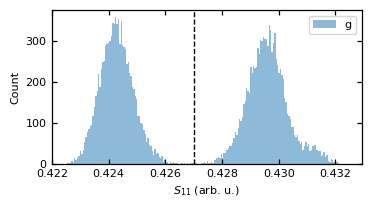

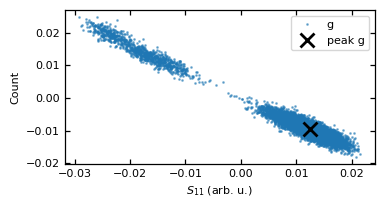

In [54]:
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()
mean_g = dd["pulse_g"]["values"].ravel()
mean_e = dd["pulse_e"]["values"].ravel()
ein_vec = (mean_e - mean_g) / np.sum((mean_e - mean_g)**2)
print(ein_vec)

proj_g = [np.dot(el - mean_g, ein_vec) for el in signal_g]
proj_e = [np.dot(el - mean_g, ein_vec) for el in signal_e]

thr = (np.mean(proj_g) + np.mean(proj_e)) / 2
thermal_population = np.mean([p > thr for p in proj_g])
print(f"thermal population: {thermal_population:.4f}")
print(len(proj_g), proj_g)
plt.figure(figsize=(4,2))
# plt.hist(proj_g, bins=200, alpha=0.5, label="g")
plt.hist(proj_g+proj_e, bins=200, alpha=0.5, label="g")
# plt.hist(proj_e, bins=200, alpha=0.5, label="e")
counts, bin_edges = np.histogram(proj_g, bins=200)
peak_bin_index = np.argmax(counts)
peak_proj_value = 0.5 * (bin_edges[peak_bin_index] + bin_edges[peak_bin_index + 1])
print("Peak projection value:", peak_proj_value)

projections = np.array([np.dot(el - mean_g, ein_vec) for el in signal_g])
idx_closest = np.argmin(np.abs(projections - peak_proj_value))

peak_point = signal_g[idx_closest]
print("Peak point (complex):", peak_point)

plt.axvline(thr, color="k", linestyle="--")

plt.xlabel("$S_{11}$ (arb. u.)")
plt.ylabel("Count")
plt.legend()
plt.show()

####################
plt.figure(figsize=(4,2))
plt.plot(signal_g.real, signal_g.imag, ".", alpha=0.5, label="g")
# plt.plot(signal_e.real, signal_e.imag, ".", alpha=0.5, label="e")

plt.plot(peak_point.real, peak_point.imag, "x", markersize=10, markeredgewidth=2, color="k", label="peak g")

plt.xlabel("$S_{11}$ (arb. u.)")
plt.ylabel("Count")
plt.legend()
plt.show()


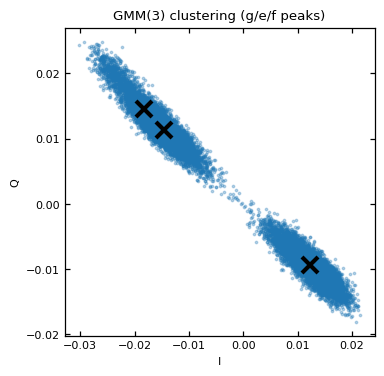

In [26]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

def to_IQ(arr):
    return np.vstack([arr.real, arr.imag]).T

X = np.vstack([to_IQ(signal_g), to_IQ(signal_e)])  # 全部まとめる

# 3つのクラスタ（g, e, f を期待）
gmm = GaussianMixture(n_components=3, covariance_type='full').fit(X)

labels = gmm.predict(X)   # 各点がどのクラスタに属するか
centers = gmm.means_      # shape (3, 2)
weights = gmm.weights_

plt.figure(figsize=(4,4))
plt.scatter(X[:,0], X[:,1], s=3, alpha=0.3)

for c in centers:
    plt.plot(c[0], c[1], "x", color="k", markersize=12, markeredgewidth=3)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("GMM(3) clustering (g/e/f peaks)")
plt.show()


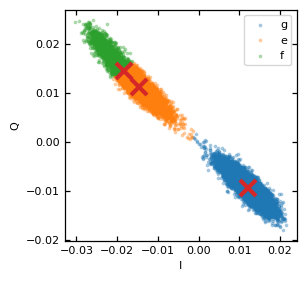

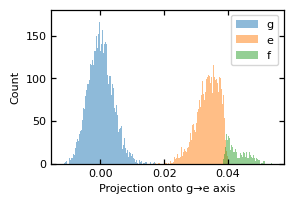

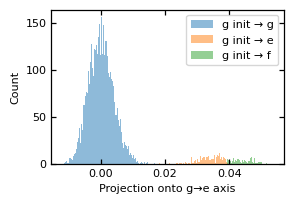

Initial state |g> → cluster fractions (g/e/f): [0.9006 0.057  0.0424]


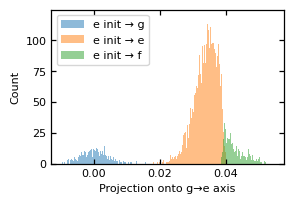

Initial state |e> → cluster fractions (g/e/f): [0.0769 0.7744 0.1487]


In [53]:
from sklearn.mixture import GaussianMixture

X = np.vstack([to_IQ(signal_g), to_IQ(signal_e)])

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    n_init=20,
    random_state=0
).fit(X)

labels = gmm.predict(X)
centers = gmm.means_

r2 = np.sum(centers**2, axis=1)
idx_sorted = np.argsort(r2)

center_g = centers[idx_sorted[0]]
center_e = centers[idx_sorted[1]]
center_f = centers[idx_sorted[2]]

label_map = np.zeros_like(labels)
for i, idx in enumerate(idx_sorted):
    label_map[labels == idx] = i   # 0=g, 1=e, 2=f

colors = ["tab:blue", "tab:orange", "tab:green"]  # g/e/f


plt.figure(figsize=(3,3))
for i, c in enumerate(colors):
    plt.scatter(
        X[label_map==i, 0], X[label_map==i, 1],
        s=3, color=c, alpha=0.3, label=f"{['g','e','f'][i]}"
    )
for i, c in enumerate(colors):
    plt.plot(centers[idx_sorted[i],0], centers[idx_sorted[i],1],
             "x", color="tab:red", markersize=12, markeredgewidth=3)

plt.xlabel("I")
plt.ylabel("Q")
# plt.title("GMM(3) clustering (g/e/f peaks)")
plt.legend()
plt.show()

vec = center_e - center_g
unit_vec = vec / np.linalg.norm(vec)
proj = (X - center_g) @ unit_vec

plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj[label_map==i], bins=200, alpha=0.5, color=c, label=f"{['g','e','f'][i]}")

plt.xlabel("Projection onto g→e axis")
plt.ylabel("Count")
# plt.title("1D Projection along g→e line")
plt.legend()
plt.show()

X_g = to_IQ(signal_g)  
X_e = to_IQ(signal_e)  

vec = center_e - center_g
unit_vec = vec / np.linalg.norm(vec)

proj_g_only = (X_g - center_g) @ unit_vec
proj_e_only = (X_e - center_g) @ unit_vec
colors = ["tab:blue", "tab:orange", "tab:green"]  # g/e/f
labels_name = ["g", "e", "f"]

N_g = len(X_g)
N_e = len(X_e)

label_map_g = label_map[:N_g]
label_map_e = label_map[N_g:]

plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj_g_only[label_map_g==i], bins=200, alpha=0.5, color=c, label=f"g init → {labels_name[i]}")

plt.xlabel("Projection onto g→e axis")
plt.ylabel("Count")
plt.legend()
plt.show()
counts_g = np.array([np.sum(label_map_g == i) for i in range(3)])
fractions_g = counts_g / counts_g.sum()
print("Initial state |g> → cluster fractions (g/e/f):", fractions_g)

plt.figure(figsize=(3,2))
for i, c in enumerate(colors):
    plt.hist(proj_e_only[label_map_e==i], bins=200, alpha=0.5, color=c, label=f"e init → {labels_name[i]}")

plt.xlabel("Projection onto g→e axis")
plt.ylabel("Count")
plt.legend()
plt.show()
counts_e = np.array([np.sum(label_map_e == i) for i in range(3)])
fractions_e = counts_e / counts_e.sum()
print("Initial state |e> → cluster fractions (g/e/f):", fractions_e)


In [40]:
print("X shape:", X.shape)
print("ein_vec shape:", ein_vec.shape)

X shape: (20000, 2)
ein_vec shape: (60,)


In [27]:
# I^2 + Q^2 が一番小さい → g
r2 = np.sum(centers**2, axis=1)
idx_sorted = np.argsort(r2)

center_g = centers[idx_sorted[0]]
center_e = centers[idx_sorted[1]]
center_f = centers[idx_sorted[2]]

from sklearn.neighbors import KNeighborsClassifier

centers_sorted = np.vstack([center_g, center_e, center_f])
labels_ref = np.array([0, 1, 2])  # g=0, e=1, f=2

clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(centers_sorted, labels_ref)

labels_pred = clf.predict(X)


readout fidelity

readout fidelity for g: 0.9978101575002105
readout fidelity for e: 0.9900470860236276


Text(0, 0.5, '$S_{11}$ (arb. u.)')

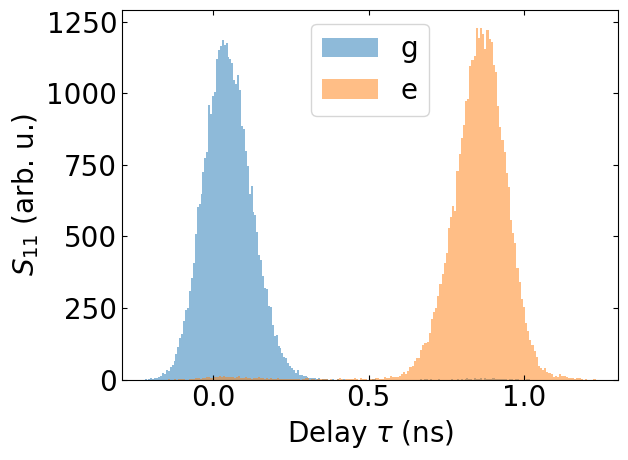

In [31]:
data = "/2025-08-13/2025-08-13T100839_0c37f003-i3_readout_fidelity" #0.7
dd =datadict_from_hdf5(header + data +"/data")
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()

plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.hist(signal_g, bins=200, alpha=0.5, log=0, label= "g")
plt.hist(signal_e, bins=200, alpha=0.5, label= "e")
print(f"readout fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g)}")
print(f"readout fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e)}")

plt.title("")
plt.legend()
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")

QND fidelity for g: 0.9984664287307606
QND fidelity for e: 0.983274907008483


Text(0, 0.5, '$S_{11}$ (arb. u.)')

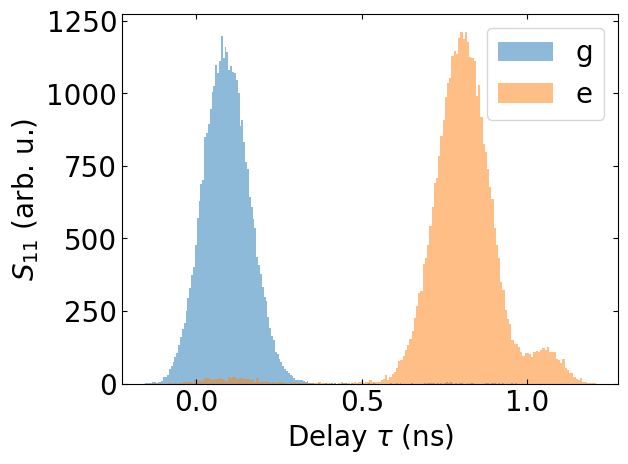

In [33]:
data = "/2025-08-13/2025-08-13T102213_f11d00cd-i4_QND_fidelity" #0.7
dd =datadict_from_hdf5(header + data +"/data")
signal_g = dd["signal_g"]["values"].ravel()
signal_e = dd["signal_e"]["values"].ravel()

plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.hist(signal_g, bins=200, alpha=0.5, log=0, label= "g")
plt.hist(signal_e, bins=200, alpha=0.5, label= "e")
print(f"QND fidelity for g: {1- len([el for el in signal_g if el>0.5])/len(signal_g)}")
print(f"QND fidelity for e: {1- len([el for el in signal_e if el<0.5])/len(signal_e)}")

plt.title("")
plt.legend()
plt.xlabel(r"Delay ${\tau}$ (ns)")
plt.ylabel("$S_{11}$ (arb. u.)")